# ValleyFever-NewsCast

## 6. Forecasting SARIMAX Modeling

## Environment Setup

Run the cell below to set up the environment for either Google Colab or local execution:

In [4]:
import os
import sys

# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")

    # Clone repository if in Colab
    if not os.path.exists('/content/ValleyFever-NewsCast/'):
        !git clone https://github.com/Adrian1840/ValleyFever-NewsCast
    os.chdir('/content/ValleyFever-NewsCast')

except ImportError:
    IN_COLAB = False
    print("Running locally")

# Add src directory to Python path
if 'src' not in sys.path:
    sys.path.append('src')

print(f"Current working directory: {os.getcwd()}")

Running in Google Colab
Cloning into 'ValleyFever-NewsCast'...
remote: Enumerating objects: 393, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 393 (delta 10), reused 1 (delta 1), pack-reused 368 (from 3)
Receiving objects: 100% (393/393), 1.72 MiB | 16.98 MiB/s, done.
Resolving deltas: 100% (148/148), done.
Current working directory: /content/ValleyFever-NewsCast


## Import Libraries and Data Loading

In [21]:
# Basic Packages
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

from sarimax_model import (
    prep_county_sarimax,
    fit_sarimax,
    evaluate_sarimax,
    check_stationarity,
    plot_pacf_plotly,
    plot_sarimax_results
)

# ----Kern County----

In [9]:
kern, X_train_k, X_test_k, y_train_k, y_test_k, train_size_k, test_size_k = prep_county_sarimax(
    aggregate_path="data/external/Kern_Aggregate.csv",
    news_features_path="data/processed/news_features_unlagged.csv",
    county="Kern"
)

In [10]:
kern.head()

,VFRate,PRECIP,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,Num_Articles,cv_mentions_rate,risk_mentions_rate
Year-Month,,,,,,,,,,,
2008-10-01,6.476629,0.04,3.483871,83.348387,78.0,76.0,0,1392.455039,0,0.0,0.0
2008-11-01,6.110027,1.46,2.956667,70.930000,131.5,63.5,0,682.323659,2,0.0,0.0
2008-12-01,5.499024,1.70,3.080645,73.777419,97.0,44.0,1,724.679851,0,0.0,0.0
2009-01-01,3.734323,0.88,2.935484,70.329032,142.0,39.0,0,215.008252,0,0.0,0.0
2009-02-01,3.975247,1.18,3.842857,92.107143,64.0,19.0,0,209.886979,1,5.0,5.0


## Kern PACF Plot

In [19]:
kern_series = np.log1p(kern["VFRate"])

fig_pacf_k = plot_pacf_plotly(
    kern_series,
    title="",
    lags=24,
    color="forestgreen"
)

fig_pacf_k.show()

## Kern ACF Plot

<Figure size 1200x600 with 0 Axes>

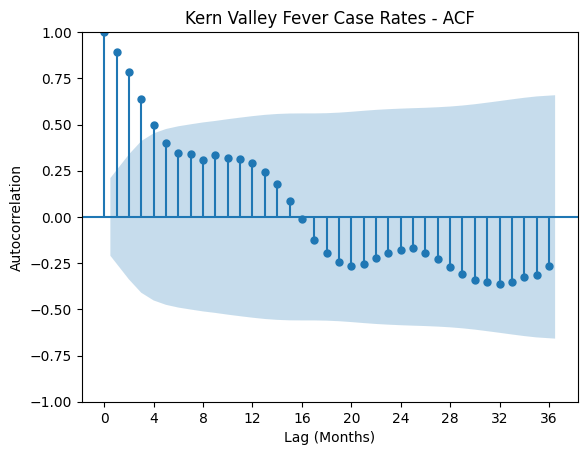

In [22]:
plt.figure(figsize=(12, 6))

plot_acf(
    kern_series,
    lags=36
)

plt.title("Kern Valley Fever Case Rates - ACF")
plt.xlabel("Lag (Months)")
plt.ylabel("Autocorrelation")
plt.xticks(range(0, 37, 4))
plt.show()



## Kern ADF Test

In [23]:
adf_k = check_stationarity(
    kern_series,
    county_name="Kern County"
)


--- Kern County Stationarity Test ---
ADF Statistic: -1.7034
p-value: 0.4293
Result: Non-Stationary


## Kern Results

In [12]:
kern_model = fit_sarimax(
    y_train_k,
    X_train_k,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12)
)

train_pred_k, test_pred_k, train_actual_k, test_actual_k, train_rmse_k, test_rmse_k = evaluate_sarimax(
    kern_model,
    y_train_k,
    y_test_k,
    X_train_k,
    X_test_k
)

print("Kern Train RMSE:", train_rmse_k)
print("Kern Test RMSE:", test_rmse_k)

Kern Train RMSE: 5.317283389571279
Kern Test RMSE: 4.873483962233412


### Plotting

In [13]:
fig_k = plot_sarimax_results(
    "Kern",
    train_actual_k,
    train_pred_k,
    test_actual_k,
    test_pred_k
)

fig_k.show()

## ----Fresno County----

In [15]:
fresno, X_train_f, X_test_f, y_train_f, y_test_f, train_size_f, test_size_f = prep_county_sarimax(
    aggregate_path="data/external/Fresno_Aggregate.csv",
    news_features_path="data/processed/news_features_unlagged.csv",
    county="Fresno"
)

## Fresno PACF Plot

In [29]:
# PACF
fresno_series = np.log1p(fresno["VFRate"])

fig_pacf_f = plot_pacf_plotly(
    fresno_series,
    title="",
    lags=24,
    color="royalblue"
)

fig_pacf_f.show()

## Kern ACF Plot

<Figure size 1200x600 with 0 Axes>

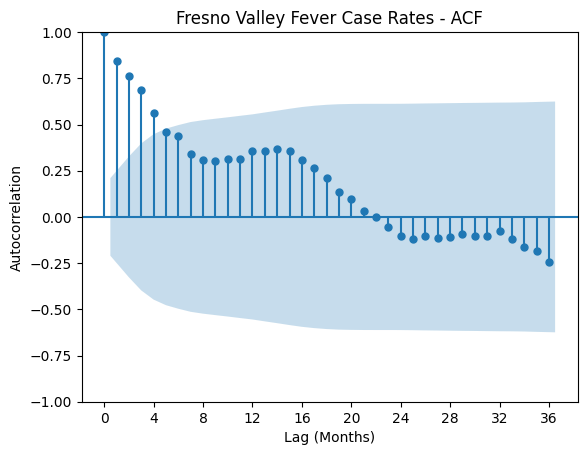

In [27]:
plt.figure(figsize=(12, 6))

plot_acf(
    fresno_series,
    lags=36
)

plt.title("Fresno Valley Fever Case Rates - ACF")
plt.xlabel("Lag (Months)")
plt.ylabel("Autocorrelation")
plt.xticks(range(0, 37, 4))
plt.show()


## Kern ADF Test

In [ ]:
adf_k = check_stationarity(
    kern_series,
    county_name="Kern County"
)


--- Kern County Stationarity Test ---
ADF Statistic: -1.7034
p-value: 0.4293
Result: Non-Stationary


### Fresno Results

In [16]:
fresno_model = fit_sarimax(
    y_train_f,
    X_train_f,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12)
)

train_pred_f, test_pred_f, train_actual_f, test_actual_f, train_rmse_f, test_rmse_f = evaluate_sarimax(
    fresno_model,
    y_train_f,
    y_test_f,
    X_train_f,
    X_test_f
)

print("Fresno Train RMSE:", train_rmse_f)
print("Fresno Test RMSE:", test_rmse_f)

Fresno Train RMSE: 1.602044237660781
Fresno Test RMSE: 1.2511747341828663


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



### Plotting

In [18]:
fig_f = plot_sarimax_results(
    "Fresno",
    train_actual_f,
    train_pred_f,
    test_actual_f,
    test_pred_f
)

fig_f.show()